In [2]:
# Importing the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
sns.set_style("whitegrid")

In [3]:
# Load dataset

dataset = load_dataset("ag_news")
dataset

Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 1767883.67 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [4]:
# Show available splits

print(dataset.keys())

# Check size of each split
print("Train size:", len(dataset["train"]))
print("Test size:", len(dataset["test"]))

dict_keys(['train', 'test'])
Train size: 120000
Test size: 7600


In [5]:
# Display a few examples

dataset["train"][:5]

{'text': ["Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
  'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.',
  "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.",
  'Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\\flows from the main pipeline in southern Iraq after\\intelligence showed a rebel militia could strike\\infrastructure, an oil official said on Saturday.',
  'Oil prices soar to all-time record, posing new menace to 

In [6]:
label_names = dataset["train"].features["label"].names
label_names

['World', 'Sports', 'Business', 'Sci/Tech']

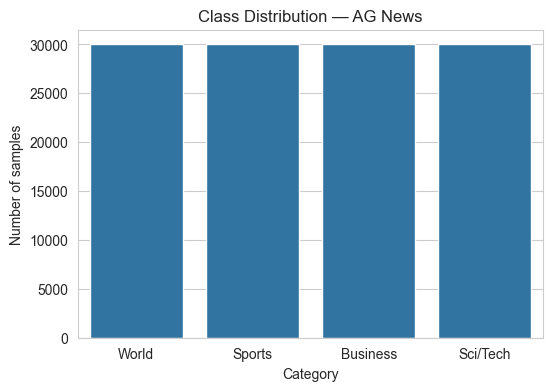

In [7]:
# Counting labels in training data

labels = dataset["train"]["label"]

label_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=label_names, y=label_counts.values)

plt.title("Class Distribution — AG News")
plt.ylabel("Number of samples")
plt.xlabel("Category")
plt.show()

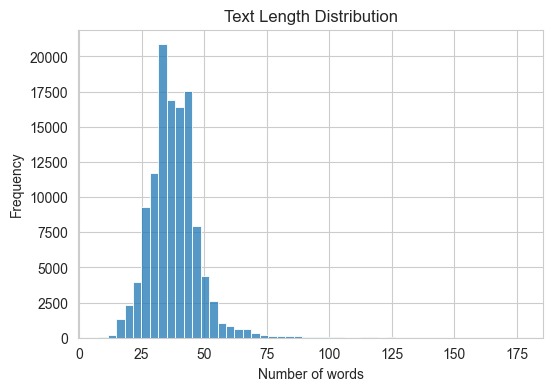

Average length: 37.84745
Max length: 177


In [8]:
# Compute text lengths

texts = dataset["train"]["text"]
lengths = [len(t.split()) for t in texts]

plt.figure(figsize=(6,4))
sns.histplot(lengths, bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

print("Average length:", np.mean(lengths))
print("Max length:", np.max(lengths))

In [9]:
from sklearn.model_selection import train_test_split

train_data = dataset["train"]

train_texts = train_data["text"]
train_labels = train_data["label"]

X_train, X_val, y_train, y_val = train_test_split(
    train_texts,
    train_labels,
    test_size=0.1,
    random_state=42,
    stratify=train_labels
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 108000
Validation samples: 12000


In [22]:
import json

# Save validation texts for later analysis

with open("../data/X_val_text.json", "w") as f:
    json.dump(X_val, f)

print("Validation texts saved")

Validation texts saved


In [10]:
# Simple preprocessing function
# Clean but not over-engineered

import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

In [11]:
from collections import Counter

# Apply preprocessing
processed_train = [preprocess_text(t) for t in X_train]

# Tokenize into words
tokenized_train = [t.split() for t in processed_train]

# Count word frequencies
word_counter = Counter()

for tokens in tokenized_train:
    word_counter.update(tokens)

# Keep most common words
vocab_size = 20000
most_common = word_counter.most_common(vocab_size)

# Create word → index mapping
word2idx = {word: i+2 for i, (word, _) in enumerate(most_common)}

# Special tokens
word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1

print("Vocabulary size:", len(word2idx))

Vocabulary size: 20002


In [12]:
def encode_text(text, word2idx):
    tokens = preprocess_text(text).split()

    ids = []
    for token in tokens:
        ids.append(word2idx.get(token, word2idx["<UNK>"]))

    return ids


# Test encoding
encode_text(X_train[0], word2idx)[:20]

[162,
 1696,
 11,
 632,
 2587,
 325,
 1991,
 1696,
 3612,
 87,
 802,
 3,
 1925,
 4,
 7805,
 5619,
 4,
 5866,
 198,
 2]

In [14]:
max_len = 100  # based on earlier length analysis

def pad_sequence(ids, max_len):
    if len(ids) > max_len:
        return ids[:max_len]
    else:
        return ids + [0] * (max_len - len(ids))


# Test
pad_sequence(encode_text(X_train[0], word2idx), max_len)[:20]

[162,
 1696,
 11,
 632,
 2587,
 325,
 1991,
 1696,
 3612,
 87,
 802,
 3,
 1925,
 4,
 7805,
 5619,
 4,
 5866,
 198,
 2]

In [15]:
def create_mask(ids):
    return [1 if token != 0 else 0 for token in ids]


sample_ids = pad_sequence(
    encode_text(X_train[0], word2idx),
    max_len
)

create_mask(sample_ids)[:20]

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [20]:
X_train_ids = [
    pad_sequence(encode_text(t, word2idx), max_len)
    for t in X_train
]

X_val_ids = [
    pad_sequence(encode_text(t, word2idx), max_len)
    for t in X_val
]

print("Training samples encoded:", len(X_train_ids))

Training samples encoded: 108000


In [21]:
import numpy as np

# Convert to arrays
X_train_ids = np.array(X_train_ids)
X_val_ids = np.array(X_val_ids)

y_train = np.array(y_train)
y_val = np.array(y_val)

# Save to disk
np.save("../data/X_train_ids.npy", X_train_ids)
np.save("../data/X_val_ids.npy", X_val_ids)

np.save("../data/y_train.npy", y_train)
np.save("../data/y_val.npy", y_val)

print("Encoded datasets saved successfully")

Encoded datasets saved successfully


In [19]:
import json

# Save vocabulary mapping
with open("../data/word2idx.json", "w") as f:
    json.dump(word2idx, f)

print("Vocabulary saved successfully")

Vocabulary saved successfully
